In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Now, we need to define the experimental datas that are given in the statement:

In [2]:
# Experimental Data

# Time (hours)
t_exp = np.array([0, 2, 6, 10])

# Sucrose concentration (mmol/L)
S_exp = np.array([1.0, 0.68, 0.16, 0.006])

# Initial concentration
S0 = S_exp[0]

print("Initial concentration S0 =", S0, "mmol/L")

Initial concentration S0 = 1.0 mmol/L


Now, we define the integrated Michaelis-Menten Model:

In [3]:
# Integrated Michaelis-Menten Model

def t_model(S, Vmax, Km):
    return (S0 - S)/Vmax + (Km/Vmax)*np.log(S0/S)

In the next code cell, we will perform a nonlinear least-squares regression to determine the values of Vmax and Km that best fit the integrated Michaelis–Menten model to the experimental batch reactor data.

In [ ]:
# Nonlinear Regression

initial_guess = [0.2, 0.1]

popt, pcov = curve_fit(t_model, S_exp, t_exp, p0=initial_guess)

Vmax_est, Km_est = popt

print("Estimated Parameters:")
print(f"Vmax = {Vmax_est:.4f} mmol/L/h")
print(f"Km = {Km_est:.4f} mmol/L")

Estimated Parameters
Vmax = 0.1994 mmol/L/h
Km = 0.1954 mmol/L


Thanks to the non linear regression in the previous cell, we obtained the optimal parameter values (popt) and the covariance matrix (pcov). We can use he covariance matrix to compute the standard deviation (uncertainty) of each parameter.

In [5]:
# Parameter Uncertainty

perr = np.sqrt(np.diag(pcov))

print("Standard deviation of Vmax =", perr[0])
print("Standard deviation of Km =", perr[1])

Standard deviation of Vmax = 0.0010597524524310347
Standard deviation of Km = 0.0023016125830121353


In [6]:
# Coefficient of Determination

t_pred = t_model(S_exp, Vmax_est, Km_est)

SS_res = np.sum((t_exp - t_pred)**2)
SS_tot = np.sum((t_exp - np.mean(t_exp))**2)

R2 = 1 - SS_res/SS_tot

print("R² =", R2)

R² = 0.9999936923769427


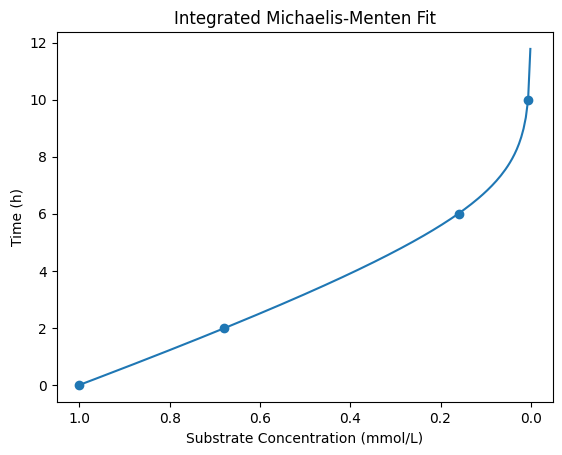

In [7]:
# Plot Results

S_smooth = np.linspace(0.001, 1, 200)
t_smooth = t_model(S_smooth, Vmax_est, Km_est)

plt.figure()
plt.scatter(S_exp, t_exp)
plt.plot(S_smooth, t_smooth)

plt.xlabel("Substrate Concentration (mmol/L)")
plt.ylabel("Time (h)")
plt.title("Integrated Michaelis-Menten Fit")
plt.gca().invert_xaxis()
plt.show()